In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

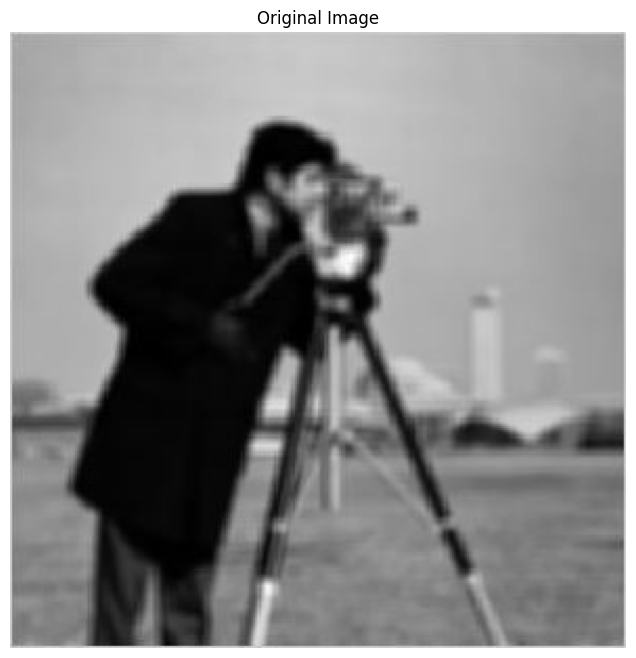

In [6]:
image_path = '../../degraded_image.png'
original = cv2.imread(image_path)
original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

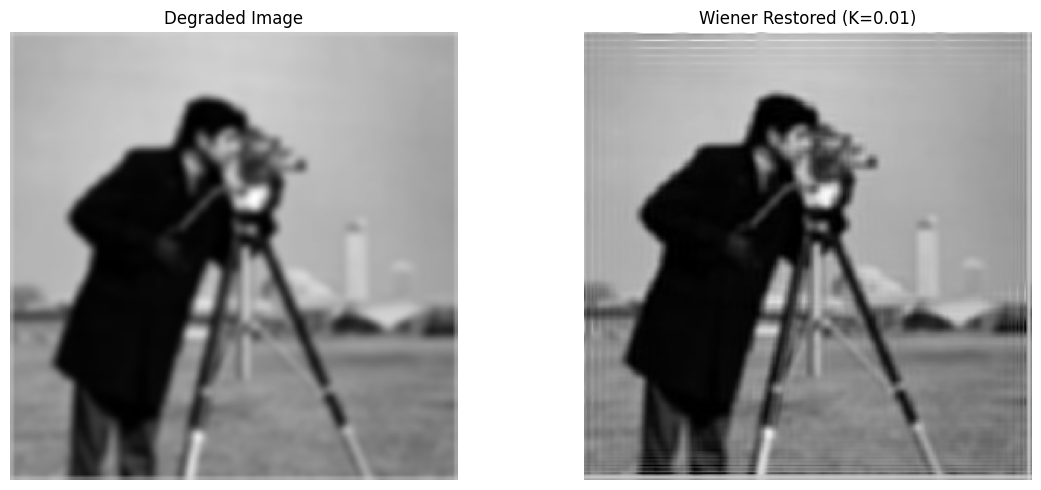

In [7]:
def inverse_filter(image, degradation_kernel):
    H = np.fft.fft2(degradation_kernel, s=image.shape)
    G = np.fft.fft2(image)

    H_inv = np.zeros_like(H, dtype=complex)
    threshold = 1e-3 * np.max(np.abs(H))

    mask = np.abs(H) > threshold
    H_inv[mask] = 1 / H[mask]

    F_restored = G * H_inv
    restored = np.fft.ifft2(F_restored).real
    restored = np.clip(restored, 0, 255)

    return restored


degradation_kernel = np.ones((5, 5)) / 25

degraded = ndimage.convolve(original_gray, degradation_kernel)
degraded = np.clip(degraded, 0, 255)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(degraded, cmap='gray')
plt.title('Degraded Image')
plt.axis('off')

restored = inverse_filter(degraded, degradation_kernel)

# Wiener filter search to improve restoration

def wiener_filter_search(image, degradation_kernel, k_values=None):
    if k_values is None:
        k_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
    G = np.fft.fft2(image)
    H = np.fft.fft2(degradation_kernel, s=image.shape)
    H_conj = np.conj(H)
    best = None
    best_mse = float('inf')
    best_img = None
    for K in k_values:
        W = H_conj / (H * H_conj + K)
        F_est = W * G
        img_est = np.fft.ifft2(F_est).real
        img_est = np.clip(img_est, 0, 255)
        try:
            mse = np.mean((original_gray - img_est) ** 2)
        except Exception:
            mse = np.mean((image - img_est) ** 2)
        if mse < best_mse:
            best_mse = mse
            best_img = img_est
            best = K
    return best_img, best, best_mse

wiener_restored, wiener_k, wiener_mse = wiener_filter_search(degraded, degradation_kernel)

plt.subplot(1, 2, 2)
plt.imshow(wiener_restored, cmap='gray')
plt.title(f'Wiener Restored (K={wiener_k})')
plt.axis('off')
plt.tight_layout()
plt.show()

Inverse filter -> MSE: 2302.76, PSNR: 14.51 dB
Wiener filter  -> MSE: 393.42, PSNR: 22.18 dB


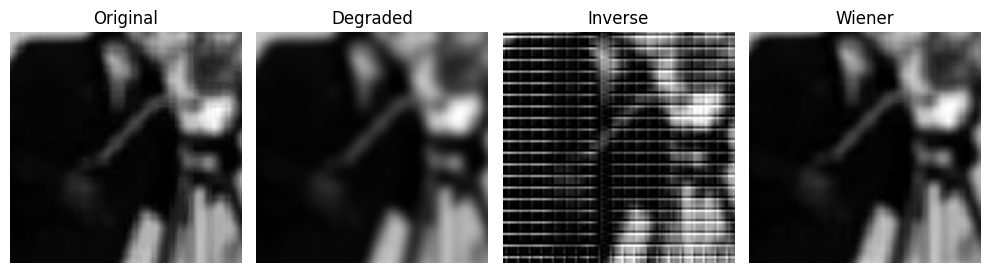

In [8]:
def compute_mse_psnr(true, pred):
    true = np.asarray(true, dtype=np.float64)
    pred = np.asarray(pred, dtype=np.float64)
    mse = np.mean((true - pred) ** 2)
    if mse == 0:
        return mse, float('inf')
    PIXEL_MAX = 255.0
    psnr = 20 * np.log10(PIXEL_MAX / np.sqrt(mse))
    return mse, psnr

mse_inv, psnr_inv = compute_mse_psnr(original_gray, restored)
mse_w, psnr_w = compute_mse_psnr(original_gray, wiener_restored)
print(f"Inverse filter -> MSE: {mse_inv:.2f}, PSNR: {psnr_inv:.2f} dB")
print(f"Wiener filter  -> MSE: {mse_w:.2f}, PSNR: {psnr_w:.2f} dB")

# show a small crop comparison to summarize differences
h, w = original_gray.shape
crop = (slice(h//4, h//4+100), slice(w//4, w//4+100))
plt.figure(figsize=(10,3))
plt.subplot(1,4,1); plt.imshow(original_gray[crop], cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(degraded[crop], cmap='gray'); plt.title('Degraded'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(restored[crop], cmap='gray'); plt.title('Inverse'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(wiener_restored[crop], cmap='gray'); plt.title('Wiener'); plt.axis('off')
plt.tight_layout()
plt.show()